# Evaluación v2 — Modelo mejorado con features manuales

En este notebook evaluamos el modelo v2 (TF-IDF + features manuales) sobre el conjunto de test
y lo comparamos con el baseline (notebook 4).

Métricas:
1. Classification report y F1-macro
2. Matriz de confusión
3. Curva ROC multiclase
4. Comparativa baseline vs v2
5. Análisis de errores
6. Registro en MLflow

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

# Localizar src/classifier/ de forma robusta y ajustar cwd al directorio
# de este notebook para que rutas relativas (datasets/, data/, model/) funcionen
# independientemente de desde donde se lance Jupyter/VS Code.
_cwd = os.getcwd()
_candidates = [
    os.path.join(_cwd, "src", "classifier"),
    os.path.abspath(".."),
    os.path.abspath("."),
]
for _p in _candidates:
    if os.path.isfile(os.path.join(_p, "functions.py")):
        if _p not in sys.path:
            sys.path.insert(0, _p)
        # Cambiar cwd al directorio de este notebook
        os.chdir(os.path.join(_p, "classifier_ultimo_dataset"))
        break

import functions  # noqa: E402
functions.MLFLOW_EXPERIMENT = "clasificador_riesgo_ultimo_dataset"
functions._DATASET_TAGS = {"dataset_type": "ultimo", "dataset_source": "dataset_sintetico_v2"}

## 1. Carga del modelo y datos de test

In [3]:
from pathlib import Path
import pandas as pd
from functions import cargar_artefactos, crear_features_manuales, combinar_features

modelo_v2, tfidf = cargar_artefactos("model")

test_path = Path("data/processed/test.csv")
if not test_path.exists():
    raise FileNotFoundError(
        f"Datos de test no encontrados: {test_path}. "
        "Ejecuta el preprocesado antes de evaluar."
    )

test_df = pd.read_csv(test_path)
X_test = test_df["text_final"]
y_test = test_df["etiqueta"]

# Reconstruir las features combinadas para test
X_test_tfidf = tfidf.transform(X_test)
feat_test = crear_features_manuales(X_test)
X_test_combined = combinar_features(X_test_tfidf, feat_test)

print(f"Test: {len(X_test)} muestras")
print(f"Features totales: {X_test_combined.shape[1]}")
print(f"Clases: {sorted(y_test.unique())}")

Modelo y vectorizador cargados correctamente.
Test: 43 muestras
Features totales: 1707
Clases: ['alto_riesgo', 'inaceptable', 'riesgo_limitado', 'riesgo_minimo']


## 2. Classification report y F1-macro

In [4]:
from sklearn.metrics import classification_report, f1_score

y_pred_v2 = modelo_v2.predict(X_test_combined)

print("=== Resultados en TEST (modelo v2) ===\n")
print(classification_report(y_test, y_pred_v2, zero_division=0))

f1_macro_v2 = f1_score(y_test, y_pred_v2, average="macro", zero_division=0)
acc_v2 = (y_pred_v2 == y_test.values).mean()
report_dict = classification_report(y_test, y_pred_v2, output_dict=True, zero_division=0)

print(f"F1-score macro (test): {f1_macro_v2:.4f}")

=== Resultados en TEST (modelo v2) ===

                 precision    recall  f1-score   support

    alto_riesgo       0.89      0.73      0.80        11
    inaceptable       0.90      0.90      0.90        10
riesgo_limitado       0.77      0.91      0.83        11
  riesgo_minimo       0.91      0.91      0.91        11

       accuracy                           0.86        43
      macro avg       0.87      0.86      0.86        43
   weighted avg       0.87      0.86      0.86        43

F1-score macro (test): 0.8606


## 3. Matriz de confusión

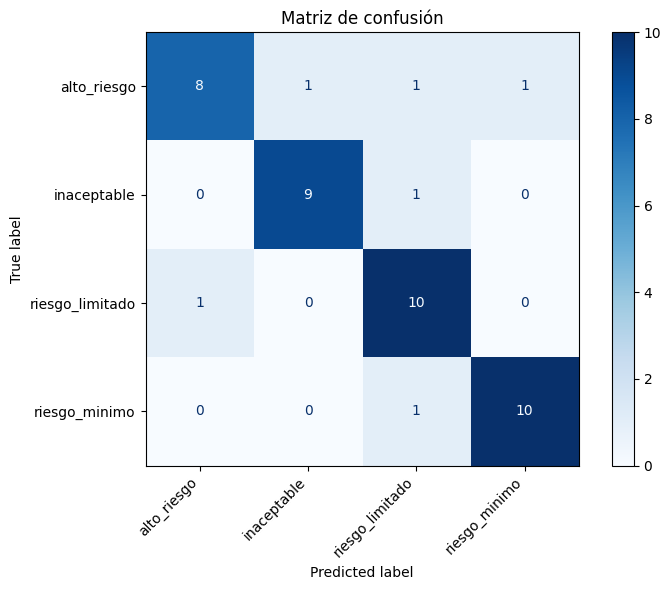

In [5]:
from functions import mostrar_matriz_confusion

clases = sorted(y_test.unique())
fig_cm = mostrar_matriz_confusion(y_test, y_pred_v2, labels=clases)

## 4. Curva ROC multiclase

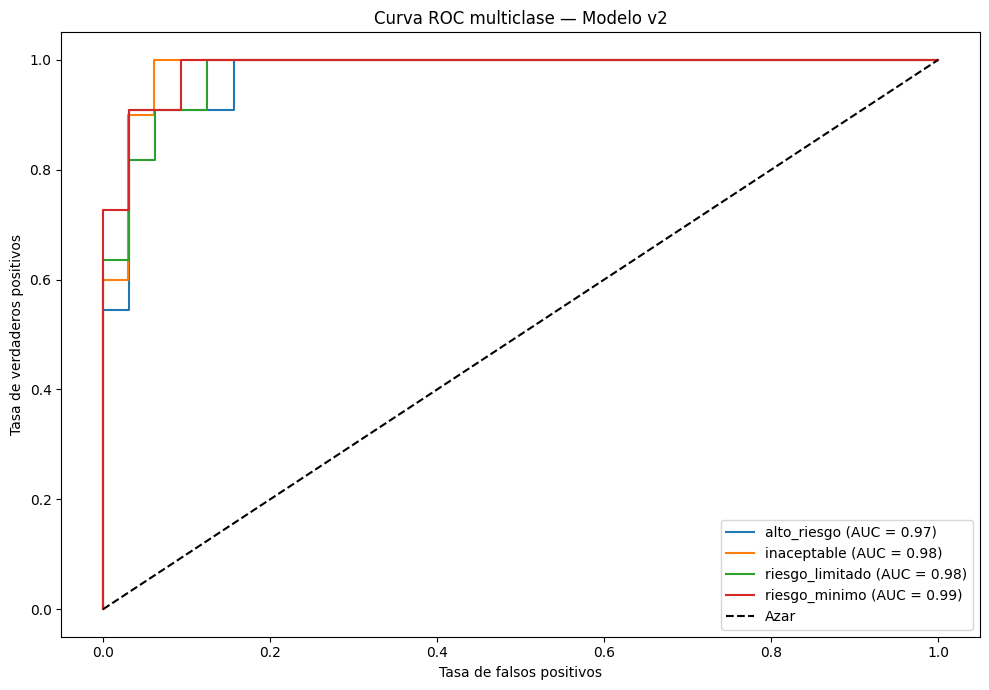


ROC AUC macro: 0.9806
  alto_riesgo: 0.9744
  inaceptable: 0.9848
  riesgo_limitado: 0.9773
  riesgo_minimo: 0.9858


In [6]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Necesitamos predict_proba sobre las features combinadas
y_proba_v2 = modelo_v2.predict_proba(X_test_combined)
y_test_bin = label_binarize(y_test, classes=clases)

fig_roc, ax = plt.subplots(figsize=(10, 7))
roc_auc_dict = {}

for i, clase in enumerate(clases):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_v2[:, i])
    roc_auc_val = auc(fpr, tpr)
    roc_auc_dict[clase] = roc_auc_val
    ax.plot(fpr, tpr, label=f"{clase} (AUC = {roc_auc_val:.2f})")

ax.plot([0, 1], [0, 1], "k--", label="Azar")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curva ROC multiclase — Modelo v2")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

roc_auc_macro = np.mean(list(roc_auc_dict.values()))
print(f"\nROC AUC macro: {roc_auc_macro:.4f}")
for clase, val in roc_auc_dict.items():
    print(f"  {clase}: {val:.4f}")

## 5. Comparativa baseline vs modelo v2

In [ ]:
import json
import os
import joblib
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from scipy.sparse import hstack, csr_matrix

# Intentar cargar métricas del baseline desde JSON; si no existe, calcularlas
# directamente cargando el modelo guardado.
try:
    with open("model/model_metadata.json") as f:
        baseline_meta = json.load(f)
    BASELINE_TEST_F1  = baseline_meta["test_f1_macro"]
    BASELINE_TEST_ACC = baseline_meta["test_accuracy"]
    BASELINE_TEST_AUC = baseline_meta["test_roc_auc"]
    print(f"Metadata baseline cargada desde JSON ({baseline_meta.get('nombre', 'modelo_baseline')})")

except FileNotFoundError:
    print("model/model_metadata.json no encontrado — calculando métricas del baseline desde modelo guardado...")

    modelo_bl = joblib.load("model/modelo_baseline.joblib")
    tfidf_bl  = joblib.load("model/tfidf_vectorizer.joblib")

    X_test_tfidf_bl = tfidf_bl.transform(X_test)

    ohe_path = "model/ohe_encoder.joblib"
    parts_bl = [X_test_tfidf_bl]
    if os.path.exists(ohe_path):
        ohe_bl   = joblib.load(ohe_path)
        ohe_cols = list(ohe_bl.feature_names_in_) if hasattr(ohe_bl, "feature_names_in_") else []
        if ohe_cols:
            cat_test_bl = ohe_bl.transform(test_df[ohe_cols])
            parts_bl.append(cat_test_bl)

    _num_cols_bl = [c for c in ["longitud", "num_articles"] if c in test_df.columns]
    if _num_cols_bl:
        num_test_bl = csr_matrix(test_df[_num_cols_bl].values.astype(float))
        parts_bl.append(num_test_bl)

    X_test_bl  = hstack(parts_bl) if len(parts_bl) > 1 else parts_bl[0]
    y_pred_bl  = modelo_bl.predict(X_test_bl)
    y_proba_bl = modelo_bl.predict_proba(X_test_bl)
    y_test_bin = label_binarize(y_test, classes=clases)

    BASELINE_TEST_F1  = f1_score(y_test, y_pred_bl, average="macro")
    BASELINE_TEST_ACC = accuracy_score(y_test, y_pred_bl)
    BASELINE_TEST_AUC = float(np.mean([
        auc(*roc_curve(y_test_bin[:, i], y_proba_bl[:, i])[:2])
        for i in range(len(clases))
    ]))

print(f"\nBaseline — F1-macro: {BASELINE_TEST_F1:.4f} | Accuracy: {BASELINE_TEST_ACC:.4f} | ROC AUC: {BASELINE_TEST_AUC:.4f}")
print()
print("=== COMPARATIVA EN TEST ===")
print(f"{'Métrica':<20} {'Baseline':>10} {'V2':>10} {'Diferencia':>12}")
print("-" * 55)
print(f"{'F1-macro':<20} {BASELINE_TEST_F1:>10.4f} {f1_macro_v2:>10.4f} {f1_macro_v2 - BASELINE_TEST_F1:>+12.4f}")
print(f"{'Accuracy':<20} {BASELINE_TEST_ACC:>10.4f} {acc_v2:>10.4f} {acc_v2 - BASELINE_TEST_ACC:>+12.4f}")
print(f"{'ROC AUC macro':<20} {BASELINE_TEST_AUC:>10.4f} {roc_auc_macro:>10.4f} {roc_auc_macro - BASELINE_TEST_AUC:>+12.4f}")

## 6. Análisis de errores

In [ ]:
df_errores = pd.DataFrame({
    "texto": X_test.values,
    "etiqueta_real": y_test.values,
    "etiqueta_predicha": y_pred_v2,
})

df_errores = df_errores[df_errores["etiqueta_real"] != df_errores["etiqueta_predicha"]]

if df_errores.empty:
    print("No hay errores de clasificación en el conjunto de test.")
else:
    print(f"Total de errores: {len(df_errores)} de {len(y_test)} "
          f"({len(df_errores)/len(y_test)*100:.1f}%)\n")
    print("Confusiones más frecuentes:")
    confusiones = df_errores.groupby(
        ["etiqueta_real", "etiqueta_predicha"]
    ).size().sort_values(ascending=False)
    print(confusiones)
    print("\nEjemplos mal clasificados:")
    for _, row in df_errores.iterrows():
        print(f"  Real: {row['etiqueta_real']} | Predicho: {row['etiqueta_predicha']}")
        print(f"  Texto: {row['texto'][:120]}...")
        print()

Total de errores: 15 de 90 (16.7%)

Confusiones más frecuentes:
etiqueta_real    etiqueta_predicha
alto_riesgo      inaceptable          5
inaceptable      riesgo_minimo        3
riesgo_limitado  riesgo_minimo        2
                 inaceptable          2
riesgo_minimo    inaceptable          2
alto_riesgo      riesgo_minimo        1
dtype: int64

Ejemplos mal clasificados:
  Real: alto_riesgo | Predicho: inaceptable
  Texto: empresa servicios legales utiliza sistema inteligencia artificial automatizar revisión contratos sistema basa datos pers...

  Real: alto_riesgo | Predicho: inaceptable
  Texto: plataforma comercio electrónico utiliza sistema inteligencia artificial generar automáticamente recomendaciones producto...

  Real: alto_riesgo | Predicho: inaceptable
  Texto: compañía seguros utiliza sistema inteligencia artificial evaluar puntuaciones riesgo asegurados mediante análisis datos ...

  Real: inaceptable | Predicho: riesgo_minimo
  Texto: herramienta extrae datos histor

## 7. Registro de métricas en MLflow

In [ ]:
# ── MLflow (solo falla esta celda si el servidor no está disponible) ──
import mlflow
from functions import configure_mlflow, MLFLOW_EXPERIMENT

# Guardar gráficos localmente (no depende del servidor)
fig_cm.savefig("model/matriz_confusion_v2.png", dpi=150, bbox_inches="tight")
fig_roc.savefig("model/curva_roc_v2.png", dpi=150, bbox_inches="tight")

try:
    configure_mlflow()
    mlflow.set_experiment(MLFLOW_EXPERIMENT)

    with mlflow.start_run(run_name="v2_evaluacion_test"):
        mlflow.log_metric("test_f1_macro",        report_dict["macro avg"]["f1-score"])
        mlflow.log_metric("test_accuracy",         report_dict["accuracy"])
        mlflow.log_metric("test_precision_macro",  report_dict["macro avg"]["precision"])
        mlflow.log_metric("test_recall_macro",     report_dict["macro avg"]["recall"])

        for clase, auc_val in roc_auc_dict.items():
            mlflow.log_metric(f"test_roc_auc_{clase}", auc_val)
        mlflow.log_metric("test_roc_auc_macro", roc_auc_macro)

        mlflow.log_artifact("model/matriz_confusion_v2.png")
        mlflow.log_artifact("model/curva_roc_v2.png")

        print("✓ Métricas de test (v2) registradas en MLflow")
        print(f"  F1-score macro: {report_dict['macro avg']['f1-score']:.4f}")
        print(f"  Run ID: {mlflow.active_run().info.run_id}")
except Exception as e:
    print(f"⚠ MLflow no disponible: {e}")

Password obtenida desde variable de entorno local.
MLflow configurado correctamente → https://18.201.64.41/
⚠ MLflow no disponible: API request to https://18.201.64.41/api/2.0/mlflow/experiments/get-by-name failed with timeout exception HTTPSConnectionPool(host='18.201.64.41', port=443): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=clasificador_riesgo_ultimo_dataset (Caused by ConnectTimeoutError(<HTTPSConnection(host='18.201.64.41', port=443) at 0x1e0c7877110>, 'Connection to 18.201.64.41 timed out. (connect timeout=120)')). To increase the timeout, set the environment variable MLFLOW_HTTP_REQUEST_TIMEOUT (default: 120, type: int) to a larger value.


## 8. Conclusiones

Documentar aquí las conclusiones:
- ¿Las features manuales mejoraron el rendimiento respecto al baseline?
- ¿Qué clases se beneficiaron más de las nuevas features?
- ¿Qué confusiones persisten y cuáles se resolvieron?
- Próximos pasos para futuras iteraciones